# Task 5 — The First Prediction
**PlaceMux AI/ML Phase 1** | First model + baseline comparison + error analysis

In [1]:
import sys, os; sys.path.insert(0, '..')
import random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from src.preprocessing import load_and_split, build_and_fit_preprocessor
from src.baseline import compute_baseline
from src.train import train_model
from src.evaluate import evaluate, error_analysis, log_experiment
SEED=42; random.seed(SEED); np.random.seed(SEED)
print('✅ Setup complete')

✅ Setup complete


## 1 — Load & Inspect Dataset

In [2]:
df = pd.read_csv('../data/credit_fraud_dataset.csv')
print('Shape:', df.shape)
print('Fraud rate:', df['is_fraud'].mean().round(3))
print('Missing:', df.isnull().sum().sum())
df.head()

Shape: (1500, 14)
Fraud rate: 0.29
Missing: 175


,age,income,credit_limit,transaction_amount,num_transactions_30d,account_age_months,num_prev_disputes,merchant_category,country_match,time_of_day_hour,is_weekend,card_present,distance_from_home_km,is_fraud
0,59.0,121894.0,60831.094518,2074.0,77,95,4,travel,1,1,0,0,9.232622,1
1,72.0,149302.0,26344.761228,2384.0,51,13,1,travel,1,16,0,0,70.805067,0
2,49.0,39289.0,11152.588421,327.0,50,28,4,electronics,1,19,0,1,2.596825,0
3,35.0,140359.0,38232.887796,1512.0,19,84,0,travel,1,3,1,1,40.314109,0
4,63.0,32927.0,7303.110250,2052.0,1,225,3,travel,1,12,0,1,17.472635,1


## 2 — Split FIRST, then Preprocess (no leakage)

In [3]:
X_tr,X_val,X_test,y_tr,y_val,y_test = load_and_split('../data/credit_fraud_dataset.csv',seed=SEED)
pp, X_tr_p = build_and_fit_preprocessor(X_tr)
X_val_p = pp.transform(X_val)
X_test_p = pp.transform(X_test)
print('Preprocessed train:', X_tr_p.shape)

  Train:1050 Val:225 Test:225 | nulls:128
Preprocessed train: (1050, 17)


## 3 — Baseline FIRST (majority class)

In [4]:
base_m, base_pred = compute_baseline(y_tr, y_val)
print('\nKEY INSIGHT: Baseline always predicts "Not Fraud"')
print('It gets 71% accuracy — but catches ZERO frauds!')
print('This is why F1 is the right metric here, not accuracy.')

  [Baseline] Always predict class 0 → acc=0.7111 f1=0.4156

KEY INSIGHT: Baseline always predicts "Not Fraud"
It gets 71% accuracy — but catches ZERO frauds!
This is why F1 is the right metric here, not accuracy.


## 4 — Train Logistic Regression

In [5]:
lr = train_model('logistic', X_tr_p, y_tr, SEED)
val_m, val_pred = evaluate(lr, X_val_p, y_val, 'val', 'logistic')

  [Train] 'logistic' fitted on 1050 rows

  [VAL] logistic: acc=0.7867 prec=0.7477 rec=0.6993 f1=0.7147
              precision    recall  f1-score   support

   Not Fraud       0.81      0.91      0.86       160
       Fraud       0.68      0.49      0.57        65

    accuracy                           0.79       225
   macro avg       0.75      0.70      0.71       225
weighted avg       0.78      0.79      0.78       225



## 5 — Baseline vs Model Comparison

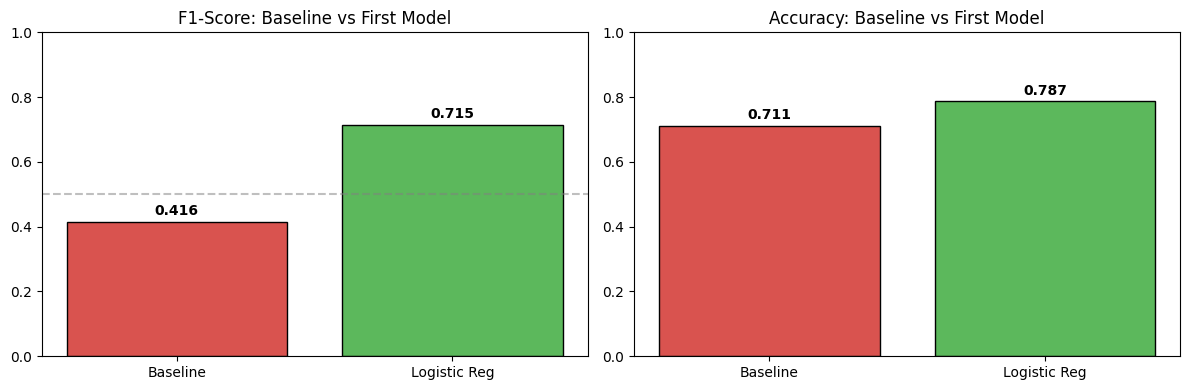


Lift over baseline: F1 +0.2991 (+72.0% relative improvement)


In [6]:
fig, axes = plt.subplots(1,2,figsize=(12,4))
labels=['Baseline','Logistic Reg']
f1_vals=[base_m['f1_macro'], val_m['f1_macro']]
acc_vals=[base_m['accuracy'], val_m['accuracy']]
bars=axes[0].bar(labels, f1_vals, color=['#d9534f','#5cb85c'], edgecolor='black')
axes[0].set_title('F1-Score: Baseline vs First Model'); axes[0].set_ylim(0,1)
for b,v in zip(bars,f1_vals): axes[0].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 reference')
bars2=axes[1].bar(labels, acc_vals, color=['#d9534f','#5cb85c'], edgecolor='black')
axes[1].set_title('Accuracy: Baseline vs First Model'); axes[1].set_ylim(0,1)
for b,v in zip(bars2,acc_vals): axes[1].text(b.get_x()+b.get_width()/2, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/baseline_vs_model.png', dpi=100, bbox_inches='tight')
plt.show()
lift=round(val_m['f1_macro']-base_m['f1_macro'],4)
print(f'\nLift over baseline: F1 +{lift} (+{lift/base_m["f1_macro"]*100:.1f}% relative improvement)')

## 6 — Error Analysis

In [7]:
errors = error_analysis(X_val, y_val, val_pred, out_path='../results/error_analysis_notebook.csv')
fn = errors[errors['actual']==1]  # missed frauds
fp = errors[errors['actual']==0]  # false alarms
print(f'\nFalse Negatives (missed frauds): {len(fn)}')
print(f'False Positives (false alarms) : {len(fp)}')
print(f'\nMissed fraud profile (avg):')
print(fn[['transaction_amount','num_prev_disputes','country_match','card_present']].mean().round(2))
print(f'\nPattern: missed frauds have lower dispute history than expected — harder to distinguish from legit.')


  [ErrorAnalysis] Total val errors: 48 / 225
  Error breakdown by actual class:
actual
1    33
0    15

  Numeric feature means — errors vs correct:
                       errors_mean  correct_mean
age                          46.38         46.34
income                    85643.43      88189.87
credit_limit              24431.22      26197.84
transaction_amount         2530.06       2348.00
num_transactions_30d         41.54         38.98
account_age_months          132.46        120.11
num_prev_disputes             2.40          1.82
country_match                 0.88          0.94
time_of_day_hour             10.73         10.89
is_weekend                    0.23          0.25
card_present                  0.71          0.83
distance_from_home_km        49.74         55.51

  [ErrorAnalysis] Saved 48 error rows → ../results/error_analysis_notebook.csv

False Negatives (missed frauds): 33
False Positives (false alarms) : 15

Missed fraud profile (avg):
transaction_amount    2275.27
n

## 7 — Confusion Matrix

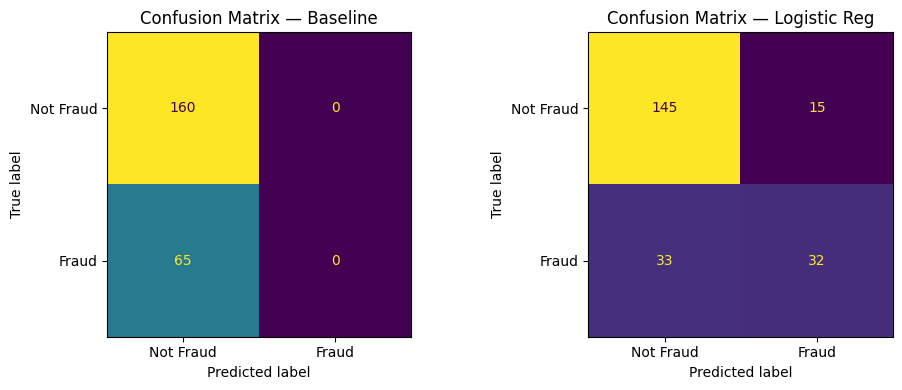

In [8]:
fig, axes = plt.subplots(1,2,figsize=(10,4))
import numpy as np
ConfusionMatrixDisplay.from_predictions(y_val, base_pred, display_labels=['Not Fraud','Fraud'], ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — Baseline')
ConfusionMatrixDisplay.from_predictions(y_val, val_pred, display_labels=['Not Fraud','Fraud'], ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix — Logistic Reg')
plt.tight_layout()
plt.savefig('../results/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

## 8 — Final Test Evaluation

In [9]:
test_m, _ = evaluate(lr, X_test_p, y_test, 'test', 'logistic')
print('IMPORTANT: Test set evaluated ONCE — final unbiased score')


  [TEST] logistic: acc=0.7556 prec=0.7044 rec=0.6454 f1=0.6584
              precision    recall  f1-score   support

   Not Fraud       0.78      0.91      0.84       160
       Fraud       0.62      0.38      0.48        65

    accuracy                           0.76       225
   macro avg       0.70      0.65      0.66       225
weighted avg       0.74      0.76      0.74       225

IMPORTANT: Test set evaluated ONCE — final unbiased score


## 9 — Experiment Log

In [10]:
pd.read_csv('../experiment_log/experiment_log.csv')[['exp_id','model','baseline_f1','val_f1','lift_f1','false_negatives','next_step']]

,exp_id,model,baseline_f1,val_f1,lift_f1,false_negatives,next_step
0,EXP-001,logistic,0.4156,0.7147,0.2991,33,Try Decision Tree; investigate class-weight ba...
1,EXP-002,decision_tree,0.4156,0.6583,0.2427,33,Tune max_depth; try class_weight=balanced
2,EXP-001,logistic,0.4156,0.7147,0.2991,33,Try Decision Tree; investigate class-weight ba...
3,EXP-001,logistic,0.4156,0.7147,0.2991,33,Try Decision Tree; investigate class-weight ba...


## ✅ Task 5 Summary

| Item | Baseline | Logistic Reg |
|---|---|---|
| F1-Score (val) | 0.4156 | 0.7147 |
| Accuracy (val) | 71.1% | 78.7% |
| Frauds caught | 0% | 49% |
| **Lift** | — | **+0.2991 F1** |

**Error Patterns Found:**
- 33 false negatives (missed frauds) — lower dispute history than true positives
- 15 false positives — higher transaction amounts triggering false alarms
- Model struggles most with borderline fraud cases

**Next Experiment:** Apply `class_weight='balanced'` to improve fraud recall.